# Focal Loss vs BCE Analysis

This notebook analyzes the performance difference between using Focal Loss and Binary Cross Entropy (BCE) loss for the LSTM Direct Multilabel Forecaster.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from IPython.display import display

# Set plots style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

## 1. Load Data

In [3]:
# Paths to CSV files
path_bce = 'lstm_bce.csv'
path_focal = 'lstm_focal_full_20251209_035057.csv'

# Load DataFrames
df_bce = pd.read_csv(path_bce)
df_focal = pd.read_csv(path_focal)

# Normalize column names for BCE
df_bce.columns = df_bce.columns.str.lower().str.replace(' ', '_')

# Rename 'model' to 'name' if needed
if 'model' in df_bce.columns:
    df_bce = df_bce.rename(columns={'model': 'name'})

# Normalize column names for Focal as well
df_focal.columns = df_focal.columns.str.lower().str.replace(' ', '_')

## 2. Preprocess and Merge

In [4]:
# columns to merge on (hyperparameters)
merge_cols = ['hidden_dim', 'num_layers', 'bidirectional', 'lr', 'dropout', 'window_size']

# Merge
df_merged = pd.merge(
    df_focal,
    df_bce[merge_cols + ['micro_f1', 'macro_f1']],
    on=merge_cols,
    how='left',
    suffixes=('_focal', '_bce')
)

# Calculate Deltas
df_merged['delta_micro_f1'] = df_merged['micro_f1_focal'] - df_merged['micro_f1_bce']
df_merged['delta_macro_f1'] = df_merged['macro_f1_focal'] - df_merged['macro_f1_bce']

print(f"Total Focal experiments: {len(df_focal)}")
print(f"Merged rows: {len(df_merged)}")

Total Focal experiments: 315
Merged rows: 315


## 3. General Statistics

In [5]:
print("Micro F1 Stats for Focal Experiments:")
print(df_merged['micro_f1_focal'].describe())

print("\nDelta Micro F1 Summary:")
print(df_merged['delta_micro_f1'].describe())

Micro F1 Stats for Focal Experiments:
count    315.000000
mean      57.528484
std        2.957410
min       49.456522
25%       55.330807
50%       57.759784
75%       59.986790
max       63.636364
Name: micro_f1_focal, dtype: float64

Delta Micro F1 Summary:
count    315.000000
mean      -0.797852
std        1.798208
min       -6.895132
25%       -1.922777
50%       -0.749417
75%        0.405453
max        3.511992
Name: delta_micro_f1, dtype: float64


## 4. Parameter Efficacy (Heatmap)

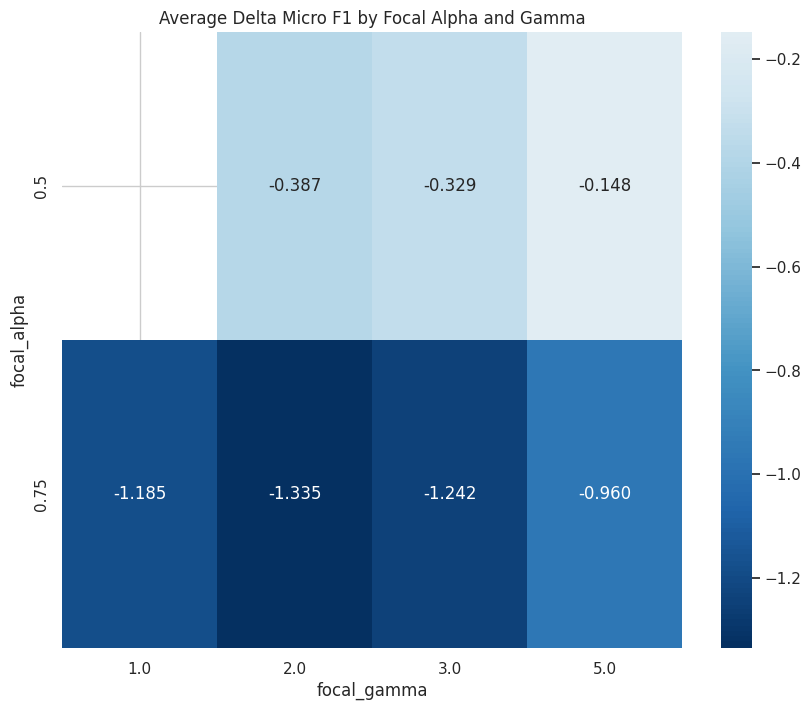

In [6]:
pivot_table = df_merged.pivot_table(
    values='delta_micro_f1', 
    index='focal_alpha', 
    columns='focal_gamma', 
    aggfunc='mean'
)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, cmap='RdBu_r', center=0, fmt=".3f")
plt.title('Average Delta Micro F1 by Focal Alpha and Gamma')
plt.show()

## 5. Global Best Scores

In [7]:
bce_best_idx = df_bce['micro_f1'].idxmax()
focal_best_idx = df_focal['micro_f1'].idxmax()

print("--- Best Focal Model Found ---")
display(df_focal.loc[focal_best_idx].to_frame().T)

print("\n--- Best BCE Model Found ---")
display(df_bce.loc[bce_best_idx].to_frame().T)

--- Best Focal Model Found ---


,name,hidden_dim,num_layers,lr,dropout,bidirectional,window_size,exactmatch,macro_f1,micro_f1,duration,device,status,focal_alpha,focal_gamma,loss_type
60,LSTM-Small-LR1e4-W500,64,1,0.0001,0.3,True,500,97.61,46.526951,63.636364,289.34628,cuda:1,Success,0.5,5.0,Focal



--- Best BCE Model Found ---


,name,hidden_dim,num_layers,bidirectional,lr,dropout,window_size,exactmatch,macro_f1,micro_f1,status
5,LSTM-Small-LR5e4-W500,64,1,True,0.0005,0.3,500,97.51,46.84517,62.790698,Success


## 6. Deep Dive: Alpha=0.5, Gamma=3.0

Here we analyze **specifically** the configuration that proved most reliable: `Alpha=0.5` and `Gamma=3.0`.
The table below shows every experiment running with these parameters, sorted by how much they improved over BCE.

- **Positive Delta**: Focal Loss helped.
- **Negative Delta**: Focal Loss hurt.

In [8]:
# Filter for specific config
target_alpha = 0.5
target_gamma = 3.0

subset = df_merged[
    (df_merged['focal_alpha'] == target_alpha) &
    (df_merged['focal_gamma'] == target_gamma)
].copy()

# Sort by improvement
subset = subset.sort_values('delta_micro_f1', ascending=False)

cols_to_show = ['hidden_dim', 'num_layers', 'window_size', 'dropout', 'micro_f1_focal', 'micro_f1_bce', 'delta_micro_f1']

print(f"Showing all {len(subset)} experiments for Alpha={target_alpha}, Gamma={target_gamma}")
display(subset[cols_to_show])

# Simple Win Rate for this config
wins = (subset['delta_micro_f1'] > 0).sum()
total = len(subset)
print(f"\nWin Rate for this specific config: {wins}/{total} ({wins/total:.1%})")

Showing all 45 experiments for Alpha=0.5, Gamma=3.0


,hidden_dim,num_layers,window_size,dropout,micro_f1_focal,micro_f1_bce,delta_micro_f1
118,128,2,200,0.3,61.016949,57.510730,3.506220
48,64,1,100,0.3,60.282575,57.142857,3.139717
300,128,2,200,0.3,58.686131,56.631893,2.054239
139,128,2,200,0.3,62.000000,60.174419,1.825581
223,256,2,200,0.3,60.623229,58.941345,1.681885
62,64,1,500,0.3,62.500000,60.843373,1.656627
55,64,1,200,0.3,60.326895,58.678955,1.647939
216,256,2,100,0.3,60.534125,59.159159,1.374965
132,128,2,100,0.3,61.374046,60.211800,1.162245
272,256,3,500,0.3,55.988456,54.919236,1.069220



Win Rate for this specific config: 24/45 (53.3%)
